# Is research-topic churn real or small-sample noise?

**A thin-sample confound check of the home-only churn/novelty signal, demonstrated on 100 concepts.**

The research artifact asks whether a concept's *neighbourhood churn* — how quickly its co-occurring topics
turn over in the early years — really predicts later spread, or whether it is an artefact of thin samples
(about 10 home papers a year). The full pipeline (stages `s0`–`s8`, run by `method.py --run-all`) computed, for
13,444 selection concepts in four bodies (DEV, OLDHO, COH1014, COH1517):

* **raw** ego-network indicators (`NOV_res`, `edge_persistence`, `ego_density_W3`, …) and the composites
  `NOVCHURN_raw` / `OPEN_home`;
* **noise-controlled variants**: V1 fixed-n rarefaction (`*_rare5`, `*_rare10`), V2 within-concept year-permutation
  null excess (`*_exc`) and Chao Jaccard (`EP_chao`), V3 configuration nulls (`z_dens_cfg`, `z_pers_cfg`, …), and the
  cleaned composites `NOVCHURN_*`, `OPEN_home_clean` / `OPEN_home_exc`;
* partial Spearman correlations with the outcome `O2r_m50`, reliability, size dependence and a power simulation.

**This notebook shows `method.py`, the orchestrator's final step (`build_outputs`).** That step:
1. standardises the five baseline covariates **B5** with the frozen EXP10 constants,
2. fits OLS models (B5 alone, and B5 plus each churn variant) on **DEV only**,
3. applies them to the held-out bodies and reports the out-of-DEV Spearman correlation with `O2r_m50`
   (the gain over B5 alone should be about 0),
4. writes one example per concept in `exp_gen_sol_out` format together with the headline verdict metadata.

The per-concept table and the full-run result summaries come from `mini_demo_data.json`: 25 concepts per body,
spread evenly over the outcome range. With 100 concepts instead of 7,748 the correlations are noisy. The
full-run values are shown next to them for comparison.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports

This is the original import block of `method.py`. The artifact's `lib/common.py` helpers (`jdump` and the path
constants) are not shipped with the demo, so the two small helpers `build_outputs` uses (`_clean`, `jdump`) are
copied verbatim below. `RES` and `ROOT` point at a local output folder. `matplotlib` is added for the final plots.

In [2]:
from __future__ import annotations

import argparse
import json
import math
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger
from scipy import stats

import matplotlib.pyplot as plt


# --- copied verbatim from the artifact's lib/common.py (only what build_outputs needs) ---
def _clean(o):
    if isinstance(o, dict):
        return {str(k): _clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_clean(v) for v in o]
    if isinstance(o, np.ndarray):
        return _clean(o.tolist())
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.bool_,)):
        return bool(o)
    if isinstance(o, (np.floating, float)):
        return None if not math.isfinite(float(o)) else float(o)
    return o


def jdump(obj, path: Path) -> None:
    Path(path).write_text(json.dumps(_clean(obj), indent=1, default=str))

## Load the demo data

The data loads from the GitHub URL, with a local fallback so the same code runs in Colab and on a local
machine.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_DVtwwCx0JbFq/round-5/experiment-16/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("examples:", len(data["datasets"][0]["examples"]))
print("full-run pooled concepts with finite outcome:", data["metadata"]["n_full_pooled_finite_outcome"])

examples: 100
full-run pooled concepts with finite outcome: 7748


## Configuration

* `N_PER_BODY` sets how many of the 25 demo concepts per body to use. The original run used every concept with a
  finite `O2r_m50`: 7,748 in total.
* `MIN_N_SPEARMAN` is the original rule in `build_outputs`: a body's Spearman correlation is reported only when
  it has more than this many concepts. It is set to 20, as in `method.py`. Because of this rule,
  `N_PER_BODY` must be at least 21 for any out-of-DEV correlation to appear.
* `OUT_DIR` is where `prediction_check.json` and `method_out.json` are written. The original wrote them to
  `results/` and to the repository root.

In [5]:
N_PER_BODY = 25          # max 25 in mini_demo_data.json (original: all concepts, 7,748 pooled)
MIN_N_SPEARMAN = 20      # original: `if ok.sum() > 20`
OUT_DIR = Path("demo_outputs")

OUT_DIR.mkdir(exist_ok=True)
ROOT = OUT_DIR           # method.py writes method_out.json to ROOT
RES = OUT_DIR            # ... and prediction_check.json to RES

## Constants from `method.py`

* **B5** lists the five baseline covariates: log volume, growth, off-home share, entropy and reach.
* **PRED_X** maps each prediction model to the churn variant it adds to B5.
* **INPUT_COLS** lists the per-concept indicators copied into each output example. Suffixes: `__raw` is the raw
  indicator, `_rare5`/`_rare10` is V1 fixed-n rarefaction, `_exc` is V2 excess over the year-permutation null,
  `_nullmean` is the V2 null mean, `EP_chao` is the V2b Chao Jaccard, and `z_*_cfg`/`z_dens_k` are the V3
  configuration-null z-scores.

The original file also defines `STAGES`, `run_stages()`, `concept_key_check()` and `exp12_crosscheck()`. Those
re-run the upstream pipeline scripts or read about 250 MB of parquet files and other artifacts' outputs, so the
demo leaves them out. Their results are marked as unavailable in the metadata below.

In [6]:
B5 = ["logvol", "growth_c", "offhome_share", "entropy", "reach"]
PRED_X = {"B5": None, "B5_plus_NOVCHURN_raw": "NOVCHURN_raw", "B5_plus_NOVCHURN_exc": "NOVCHURN_exc",
          "B5_plus_NOVCHURN_cfg": "NOVCHURN_cfg", "B5_plus_OPEN_home": "OPEN_home",
          "B5_plus_OPEN_home_clean": "OPEN_home_clean"}
INPUT_COLS = ["NOV_res__raw", "edge_persistence__raw", "ego_density_W3__raw", "new_edge_rate__raw", "n_comm_W3__raw",
              "participation__raw", "NOVCHURN_raw", "OPEN_home", "NOV_res_rare10", "edge_persistence_rare10",
              "NOVCHURN_rare10", "NOV_res_rare5", "edge_persistence_rare5", "NOVCHURN_rare5", "NOV_res_exc",
              "edge_persistence_exc", "edge_persistence_nullmean", "NOVCHURN_exc", "EP_chao", "NOVCHURN_chao",
              "z_dens_cfg", "z_dens_k", "z_pers_cfg", "excess_pers_cfg", "NOVCHURN_cfg", "OPEN_home_clean",
              "OPEN_home_exc"]

## `build_outputs()`, part 1: inputs

In the original, `spec`, `V`, `rel`, `pw` and `sz` are read from `results/*.json`, and `T` comes from
`tables.load_tables()["POOLED"]`, which joins `clean_variants.parquet` with the EXP10 covariates and outcomes.
Here they come from `data`. Missing values arrive as JSON `null` and become `NaN` again, so the `np.isfinite`
logic works as in the original. The last line, which keeps only concepts with a finite outcome, is unchanged.

In [7]:
meta_in = data["metadata"]
spec = meta_in["frozen_spec"]                  # was: json.loads((RES / "frozen_spec.json").read_text())
pm = spec["exp10_prediction_models"]["B5"]
V = meta_in["clean_vs_raw_psp"]                # was: results/clean_vs_raw_psp.json
rel = meta_in["reliability"]                   # was: results/reliability.json
pw = meta_in["power_frame_n"]                  # was: results/power_frame_n.json
sz = meta_in["size_dependence"]                # was: results/size_dependence.json

# was: T = load_tables()["POOLED"]
T = pd.DataFrame(data["datasets"][0]["examples"])
# demo: keep N_PER_BODY concepts per body, spread evenly over the (outcome-sorted) demo rows
T = pd.concat([g.iloc[np.unique(np.linspace(0, len(g) - 1, min(N_PER_BODY, len(g))).round().astype(int))]
               for _, g in T.groupby("body", sort=False)], ignore_index=True)
for c in T.columns:
    if c not in ("name", "body", "agroup"):
        T[c] = pd.to_numeric(T[c], errors="coerce").astype(float)           # JSON null -> NaN
T = T[np.isfinite(T.O2r_m50)].reset_index(drop=True)
print(T.body.value_counts().to_dict())
print("frozen B5 mu:", pm["mu"])
T.head()

{'DEV': 25, 'OLDHO': 25, 'COH1014': 25, 'COH1517': 25}
frozen B5 mu: {'logvol': 4.387217461299273, 'growth_c': 0.13591487868338373, 'offhome_share': 0.2628714872549475, 'entropy': 0.7831561038968538, 'reach': 3.228179741051028}


,concept_id,name,body,agroup,t0,n_home_early,O2r_m50,O2r_resid,logvol,growth_c,...,NOVCHURN_exc,EP_chao,NOVCHURN_chao,z_dens_cfg,z_dens_k,z_pers_cfg,excess_pers_cfg,NOVCHURN_cfg,OPEN_home_clean,OPEN_home_exc
0,2.779619e+09,Essure,DEV,BGM+Med,2007.0,91.0,1.000000,-3.555508,4.574711,0.060625,...,NaN,0.589709,NaN,12.917785,7.374662,NaN,0.466667,NaN,0.546166,0.476757
1,2.780843e+09,Repetitive control,DEV,CS+Eng,2006.0,46.0,1.778275,-2.506377,3.891820,-0.451985,...,NaN,0.295064,NaN,5.250850,3.644957,-0.070888,-0.001250,NaN,-0.043806,-0.624409
2,2.780181e+09,Inflammatory myopathy,DEV,BGM+Med,2009.0,43.0,2.000000,-2.420414,4.234107,-0.080043,...,NaN,0.377014,NaN,6.745767,6.378029,-0.119459,-0.001833,NaN,0.498401,0.339562
3,2.777704e+09,Breast surgery,DEV,BGM+Med,2003.0,66.0,2.436791,-2.027133,4.343805,0.039221,...,0.668963,0.534446,-0.497612,11.374851,12.523143,17.562992,0.209509,-0.013754,0.486722,0.498492
4,8.348757e+07,Space–time block code,DEV,CS+Eng,2005.0,59.0,2.704225,-1.821575,4.499810,-0.188052,...,0.204912,0.990000,-1.795334,17.410448,9.236480,10.938635,0.164405,-0.265948,-0.469926,-0.217427


## Part 2: fit OLS on DEV and predict every body

The B5 covariates are standardised with the frozen EXP10 `mu`/`sd`, **not** refitted on this sample. For each
model that adds a churn variant, NaN values are imputed with the DEV median and flagged. The OLS coefficients
come from the DEV rows only and are then applied to every concept. This code is unchanged.

In [8]:
Zb = np.column_stack([(T[c].to_numpy(float) - pm["mu"][c]) / pm["sd"][c] for c in B5])
dev = (T.body == "DEV").to_numpy() & np.all(np.isfinite(Zb), 1)
y = T.O2r_m50.to_numpy(float)
preds, imputed, coefs = {}, {}, {}
for nm, x in PRED_X.items():
    X = Zb.copy()
    if x is not None:
        v = T[x].to_numpy(float)
        med = float(np.nanmedian(v[dev]))
        imputed[nm] = ~np.isfinite(v)
        v = np.where(np.isfinite(v), v, med)
        X = np.c_[X, v]
    A = np.c_[np.ones(len(T)), X]
    okf = dev & np.all(np.isfinite(A), 1)
    b = np.linalg.lstsq(A[okf], y[okf], rcond=None)[0]
    coefs[nm] = b.tolist()
    preds[nm] = A @ b
for nm in coefs:
    print(f"{nm:26s} n_DEV_fit={int(dev.sum()):3d}  coef={np.round(coefs[nm], 3).tolist()}")

B5                         n_DEV_fit= 25  coef=[5.349, -0.606, 0.522, -4.472, 6.952, -1.366]
B5_plus_NOVCHURN_raw       n_DEV_fit= 25  coef=[5.323, -0.572, 0.477, -4.472, 6.916, -1.339, 0.103]
B5_plus_NOVCHURN_exc       n_DEV_fit= 25  coef=[5.199, -0.627, 0.485, -4.278, 6.738, -1.296, 0.273]
B5_plus_NOVCHURN_cfg       n_DEV_fit= 25  coef=[5.288, -0.605, 0.515, -4.424, 6.888, -1.351, 0.147]
B5_plus_OPEN_home          n_DEV_fit= 25  coef=[5.459, -0.631, 0.712, -4.686, 7.326, -1.566, -0.304]
B5_plus_OPEN_home_clean    n_DEV_fit= 25  coef=[5.379, -0.601, 0.538, -4.535, 7.029, -1.386, -0.056]


## Part 3: out-of-DEV check

For each held-out body, this computes the Spearman correlation between each model's prediction and the observed
`O2r_m50`, and the gain over B5 alone. In the full run every gain was about 0 (below +0.005). The churn variants
add almost nothing to *out-of-sample prediction* beyond B5, although their partial correlations are non-zero.
The code is unchanged except that `20` is now the config variable `MIN_N_SPEARMAN`.

In [9]:
chk = {"note": "OLS fitted on DEV only; out-of-DEV Spearman with O2r_m50 (gain over B5 expected ~0)", "coef": coefs}
for body in ("OLDHO", "COH1014", "COH1517"):
    m = (T.body == body).to_numpy()
    ent = {}
    for nm, p in preds.items():
        ok = m & np.isfinite(p)
        ent[nm] = float(stats.spearmanr(p[ok], y[ok])[0]) if ok.sum() > MIN_N_SPEARMAN else None
    ent["n"] = int(m.sum())
    ent["gain_vs_B5"] = {nm: (ent[nm] - ent["B5"]) if ent[nm] is not None and ent["B5"] is not None else None
                         for nm in PRED_X if nm != "B5"}
    chk[body] = ent
jdump(chk, RES / "prediction_check.json")
print(json.dumps({b: {k: v for k, v in chk[b].items() if k != "gain_vs_B5"} for b in ("OLDHO", "COH1014", "COH1517")},
                 indent=1))

{
 "OLDHO": {
  "B5": 0.5153846153846153,
  "B5_plus_NOVCHURN_raw": 0.5207692307692308,
  "B5_plus_NOVCHURN_exc": 0.5007692307692309,
  "B5_plus_NOVCHURN_cfg": 0.5207692307692308,
  "B5_plus_OPEN_home": 0.5115384615384615,
  "B5_plus_OPEN_home_clean": 0.5269230769230769,
  "n": 25
 },
 "COH1014": {
  "B5": 0.7315384615384616,
  "B5_plus_NOVCHURN_raw": 0.726153846153846,
  "B5_plus_NOVCHURN_exc": 0.7276923076923076,
  "B5_plus_NOVCHURN_cfg": 0.7353846153846154,
  "B5_plus_OPEN_home": 0.7569230769230769,
  "B5_plus_OPEN_home_clean": 0.7438461538461538,
  "n": 25
 },
 "COH1517": {
  "B5": 0.41692307692307695,
  "B5_plus_NOVCHURN_raw": 0.4123076923076923,
  "B5_plus_NOVCHURN_exc": 0.4153846153846154,
  "B5_plus_NOVCHURN_cfg": 0.39999999999999997,
  "B5_plus_OPEN_home": 0.3638461538461538,
  "B5_plus_OPEN_home_clean": 0.4115384615384615,
  "n": 25
 }
}


## Part 4: one output example per concept (`exp_gen_sol_out` format)

Each example stores the concept's raw and cleaned indicators as the JSON `input` and `O2r_m50` as the `output`.
It also holds one `predict_<model>` field per OLS model and metadata flags that show which variants were imputed
or missing. This code is unchanged.

In [10]:
exs = []
for i, r in T.iterrows():
    inp = {"concept_id": str(r.concept_id), "name": str(r["name"]), "body": r.body, "t0": int(r.t0),
           "n_home_early": int(r.n_home_early)}
    for c in INPUT_COLS:
        v = r[c]
        inp[c] = None if not np.isfinite(v) else round(float(v), 6)
    e = {"input": json.dumps(inp), "output": f"{r.O2r_m50:.6f}"}
    for nm, p in preds.items():
        e[f"predict_{nm}"] = f"{p[i]:.6f}" if np.isfinite(p[i]) else "nan"
    e["metadata_body"] = r.body
    e["metadata_agroup"] = r.agroup
    e["metadata_O2r_resid"] = None if not np.isfinite(r.O2r_resid) else float(r.O2r_resid)
    e["metadata_imputed_variants"] = [nm for nm in imputed if imputed[nm][i]]
    e["metadata_missing_clean_variants"] = [c for c in ("NOVCHURN_exc", "NOVCHURN_rare10", "NOVCHURN_cfg",
                                                        "OPEN_home_clean") if not np.isfinite(r[c])]
    exs.append(e)
print(len(exs), "examples; first one:")
print(json.dumps(exs[0], indent=1)[:1500])

100 examples; first one:
{
 "input": "{\"concept_id\": \"2779619083.0\", \"name\": \"Essure\", \"body\": \"DEV\", \"t0\": 2007, \"n_home_early\": 91, \"NOV_res__raw\": null, \"edge_persistence__raw\": 0.466667, \"ego_density_W3__raw\": 1.0, \"new_edge_rate__raw\": 0.0, \"n_comm_W3__raw\": 3.0, \"participation__raw\": 0.65625, \"NOVCHURN_raw\": null, \"OPEN_home\": -0.141717, \"NOV_res_rare10\": null, \"edge_persistence_rare10\": 0.105, \"NOVCHURN_rare10\": null, \"NOV_res_rare5\": null, \"edge_persistence_rare5\": 0.035714, \"NOVCHURN_rare5\": null, \"NOV_res_exc\": null, \"edge_persistence_exc\": -0.023699, \"edge_persistence_nullmean\": 0.490366, \"NOVCHURN_exc\": null, \"EP_chao\": 0.589709, \"NOVCHURN_chao\": null, \"z_dens_cfg\": 12.917785, \"z_dens_k\": 7.374662, \"z_pers_cfg\": null, \"excess_pers_cfg\": 0.466667, \"NOVCHURN_cfg\": null, \"OPEN_home_clean\": 0.546166, \"OPEN_home_exc\": 0.476757}",
 "output": "1.000000",
 "predict_B5": "1.688080",
 "predict_B5_plus_NOVCHURN_raw"

## Part 5: verdict metadata and `method_out.json`

This part assembles the headline metadata from the full-run summaries:
* the mechanical verdict (`PARTLY_THIN`);
* whether predictions P1–P3 hold;
* the headline partial Spearman (psp, controlling for B5 and R2) of each variant with `O2r_m50`;
* the Spearman–Brown reliabilities;
* the thin-sample share of raw persistence;
* the plain-language power statement.

`concept_key_check()` and `exp12_crosscheck()` are replaced by an "unavailable in demo" note, because they read
external artifacts. The rest is unchanged.

In [11]:
vd = V["verdict"]
head = {h["variant"]: {b: h[b].get("psp") for b in ("DEV", "OLDHO", "COH1014", "COH1517", "POOLED")}
        for h in V["headline_R2_O2r_m50"]}
_NA = {"available": False, "note": "needs external artifacts; not run in the demo"}
meta = {"method_name": "Thin-sample confound check of home-only neighbourhood churn (raw vs noise-controlled "
                       "variants)",
        "label": "selection data, outcomes previously unsealed: robustness evidence, not confirmation",
        "verdict": vd["verdict"], "DEGREE_ARTEFACT_PERSISTENCE": vd["DEGREE_ARTEFACT_PERSISTENCE"],
        "predictions_P1_P3": {k: v["holds"] for k, v in V["predictions"].items()},
        "P_detail": V["predictions"], "headline_psp_R2_O2r_m50": head,
        "reliability_pooled_SB": {k: v["pooled"]["SB"] for k, v in rel["variants"].items()},
        "outcome_reliability_SB": rel["outcome"]["O2r_m50"]["pooled"]["SB"],
        "thin_sample_share_R2": sz["thin_sample_share"]["POOLED"]["R2"],
        "power_plain_language": pw["plain_language"],
        "concept_key_check": _NA, "exp12_home_crosscheck": _NA,   # was: concept_key_check(), exp12_crosscheck()
        "n_examples": len(exs), "prediction_models": "OLS on DEV (B5 standardised with EXP10 frozen mu/sd); "
                                                     "NaN variants imputed with the DEV median (flagged)"}
out = {"metadata": meta, "datasets": [{"dataset": "selection_concepts", "examples": exs}]}
(ROOT / "method_out.json").write_text(json.dumps(out, indent=1, default=lambda o: None if isinstance(o, float)
                                                 and not math.isfinite(o) else str(o)))
logger.info(f"method_out.json: {len(exs)} examples; verdict {vd['verdict']}")
print("P1-P3 hold:", meta["predictions_P1_P3"])
print("thin-sample share of raw persistence (R2):", round(meta["thin_sample_share_R2"], 3))
print("power:", meta["power_plain_language"])

2026-09-29 21:38:44.879 | INFO     | __main__:<module>:21 - method_out.json: 100 examples; verdict PARTLY_THIN


P1-P3 hold: {'P1': False, 'P2': True, 'P3': True}
thin-sample share of raw persistence (R2): 0.66
power: At n = 800 (S_A, T3 = half the pooled raw estimate) joint power (OPEN_home R3 & R5 & NOVCHURN_raw R3) = 0.07; at n = 2500 it is 0.26. With T2 (COH1517 raw) it is 0.31 / 0.75. Pessimistic n-mix (S_B, T3): 0.03 / 0.06. The fallback O2r_m30 outcome set is not simulated here (out of scope); analytic n for 0.8 marginal power per index is in n_for_80pct_marginal.


## Results and visualisation

1. **Out-of-DEV Spearman**: each model's value on the demo subset next to the full run. The absolute values
   differ because of the small sample, but in both the churn variants barely change the B5 baseline.
2. **Headline partial Spearman** (full run, pooled, 95% bootstrap CI) of the raw and noise-controlled churn
   variants. The V2 excess variants (`*_exc`, `*_zperm`) collapse to about 0. Rarefaction keeps part of the
   signal, and Chao and configuration-null composites keep most of it. This is the `PARTLY_THIN` verdict.
3. **Predicted vs observed** `O2r_m50` on the demo concepts for B5 alone and for B5 + `NOVCHURN_raw`.

Out-of-DEV Spearman(prediction, O2r_m50): demo subset vs full run
   body                   model  demo_spearman  full_spearman  demo_n  full_n
  OLDHO                      B5         0.5154         0.7051      25    1797
  OLDHO    B5_plus_NOVCHURN_raw         0.5208         0.7101      25    1797
  OLDHO    B5_plus_NOVCHURN_exc         0.5008         0.7051      25    1797
  OLDHO    B5_plus_NOVCHURN_cfg         0.5208         0.7068      25    1797
  OLDHO       B5_plus_OPEN_home         0.5115         0.7068      25    1797
  OLDHO B5_plus_OPEN_home_clean         0.5269         0.7070      25    1797
COH1014                      B5         0.7315         0.7589      25    2154
COH1014    B5_plus_NOVCHURN_raw         0.7262         0.7621      25    2154
COH1014    B5_plus_NOVCHURN_exc         0.7277         0.7588      25    2154
COH1014    B5_plus_NOVCHURN_cfg         0.7354         0.7608      25    2154
COH1014       B5_plus_OPEN_home         0.7569         0.7610      25    215

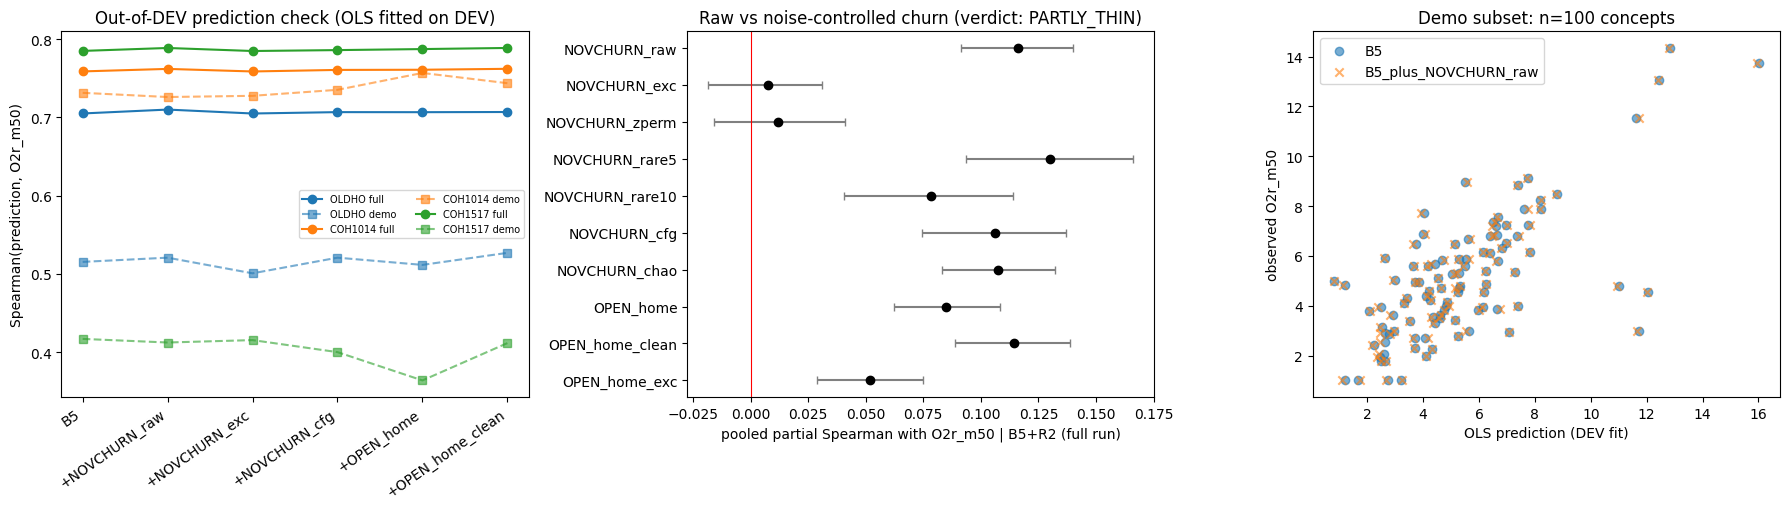

In [12]:
full_pc = meta_in["full_run_prediction_check"]
rows = []
for body in ("OLDHO", "COH1014", "COH1517"):
    for nm in PRED_X:
        rows.append({"body": body, "model": nm, "demo_spearman": chk[body][nm],
                     "full_spearman": full_pc[body][nm], "demo_n": chk[body]["n"], "full_n": full_pc[body]["n"]})
res = pd.DataFrame(rows)
pd.set_option("display.width", 160)
print("Out-of-DEV Spearman(prediction, O2r_m50): demo subset vs full run")
print(res.round(4).to_string(index=False))

print("\nVerdict:", meta["verdict"], "| P1-P3:", meta["predictions_P1_P3"])
print("Reliability (Spearman-Brown, pooled):",
      {k: round(meta["reliability_pooled_SB"][k], 3) for k in ("NOVCHURN_raw", "NOVCHURN_exc", "OPEN_home", "OPEN_home_clean")
       if k in meta["reliability_pooled_SB"]}, "| outcome:", round(meta["outcome_reliability_SB"], 3))

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))

# (1) out-of-DEV spearman, demo vs full
ax = axes[0]
piv_d = res.pivot(index="model", columns="body", values="demo_spearman").loc[list(PRED_X)]
piv_f = res.pivot(index="model", columns="body", values="full_spearman").loc[list(PRED_X)]
xx = np.arange(len(PRED_X))
for j, body in enumerate(("OLDHO", "COH1014", "COH1517")):
    ax.plot(xx, piv_f[body], "o-", color=f"C{j}", label=f"{body} full")
    ax.plot(xx, piv_d[body].astype(float), "s--", color=f"C{j}", alpha=0.6, label=f"{body} demo")
ax.set_xticks(xx, [m.replace("B5_plus_", "+") for m in PRED_X], rotation=35, ha="right")
ax.set_ylabel("Spearman(prediction, O2r_m50)")
ax.set_title("Out-of-DEV prediction check (OLS fitted on DEV)")
ax.legend(fontsize=7, ncol=2)

# (2) headline pooled psp with CI for the churn variants
ax = axes[1]
hv = [h for h in V["headline_R2_O2r_m50"] if h["variant"].startswith(("NOVCHURN", "OPEN_home"))]
names = [h["variant"] for h in hv]
ps = np.array([h["POOLED"]["psp"] for h in hv], float)
ci = np.array([h["POOLED"]["ci"] for h in hv], float)
yy = np.arange(len(hv))[::-1]
ax.errorbar(ps, yy, xerr=[ps - ci[:, 0], ci[:, 1] - ps], fmt="o", color="k", ecolor="grey", capsize=3)
ax.axvline(0, color="r", lw=0.8)
ax.set_yticks(yy, names)
ax.set_xlabel("pooled partial Spearman with O2r_m50 | B5+R2 (full run)")
ax.set_title("Raw vs noise-controlled churn (verdict: %s)" % vd["verdict"])

# (3) predicted vs observed on the demo subset
ax = axes[2]
for nm, mk in (("B5", "o"), ("B5_plus_NOVCHURN_raw", "x")):
    ax.scatter(preds[nm], y, marker=mk, alpha=0.6, label=nm)
ax.set_xlabel("OLS prediction (DEV fit)")
ax.set_ylabel("observed O2r_m50")
ax.set_title(f"Demo subset: n={len(T)} concepts")
ax.legend()
plt.tight_layout()
plt.show()